In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Function
from torch.jit import script
from collections import OrderedDict

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import QuantileTransformer, LabelEncoder
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix,
    matthews_corrcoef, cohen_kappa_score,
    classification_report, roc_curve,
    precision_recall_curve, average_precision_score
)

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Thiết bị: {device}')
print(f'PyTorch : {torch.__version__}')


Thiết bị: cuda
PyTorch : 2.9.0+cu126


In [2]:
DATA_PATH = '/kaggle/input/datasets/iqsnguyn/lancuoidibennhau/Denguediseasesdataset1003.csv_clean.csv'  
LABEL_COL = 'Final Output'           

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f'Tải dữ liệu thực: {df.shape}')
_le = LabelEncoder()
df[LABEL_COL] = _le.fit_transform(df[LABEL_COL])
LABEL_NAMES   = {int(i): str(c) for i, c in enumerate(_le.classes_)}
print(f'Mapping nhãn : {LABEL_NAMES}')
print(f'Shape        : {df.shape}')
print(f'Phân phối    :\n{df[LABEL_COL].value_counts().rename(LABEL_NAMES)}')
df.head()


Tải dữ liệu thực: (931, 9)
Mapping nhãn : {0: '0.0', 1: '1.0'}
Shape        : (931, 9)
Phân phối    :
Final Output
1.0    631
0.0    300
Name: count, dtype: int64


,Age,Sex,Haemoglobin,WBC Count,Differential Count,RBC PANEL,Platelet Count,PDW,Final Output
0,43,Male,12.6,2200.0,1,1,62000.0,11.0,1
1,45,Male,13.2,3000.0,0,1,17000.0,17.0,1
2,50,Female,11.0,3300.0,1,1,19000.0,16.3,1
3,57,Female,11.9,3500.0,1,0,29000.0,14.0,1
4,51,Female,13.0,3100.0,0,1,30000.0,14.5,1


In [3]:
print(df.info())
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 931 entries, 0 to 930
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 931 non-null    int64  
 1   Sex                 931 non-null    object 
 2   Haemoglobin         931 non-null    float64
 3   WBC Count           931 non-null    float64
 4   Differential Count  931 non-null    int64  
 5   RBC PANEL           931 non-null    int64  
 6   Platelet Count      931 non-null    float64
 7   PDW                 931 non-null    float64
 8   Final Output        931 non-null    int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 65.6+ KB
None


,Age,Haemoglobin,WBC Count,Differential Count,RBC PANEL,Platelet Count,PDW,Final Output
count,931.00,931.00,931.00,931.00,931.00,931.00,931.00,931.00
mean,42.45,13.73,4336.31,0.94,0.94,114396.06,22.97,0.68
std,20.88,1.48,2349.77,0.24,0.24,89113.87,14.87,0.47
min,3.00,11.00,2000.00,0.00,0.00,10000.00,1.00,0.00
25%,27.00,12.60,2600.00,1.00,1.00,46000.00,14.00,0.00
50%,41.00,13.70,3200.00,1.00,1.00,93000.00,17.90,1.00
75%,55.00,15.00,6200.00,1.00,1.00,162500.00,28.80,1.00
max,120.00,25.00,10900.00,1.00,1.00,500000.00,215.00,1.00


Không có giá trị thiếu.


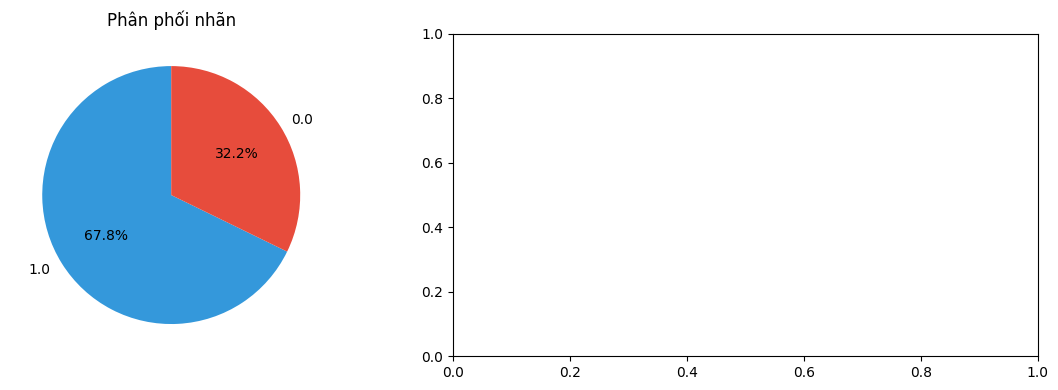

In [4]:
missing = df.isnull().sum()
if missing.sum() == 0:
    print('Không có giá trị thiếu.')
else:
    print('Giá trị thiếu:')
    print(missing[missing > 0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df[LABEL_COL].value_counts()
axes[0].pie(counts, labels=[LABEL_NAMES[k] for k in counts.index],
            autopct='%1.1f%%', colors=['#3498db','#e74c3c'], startangle=90)
axes[0].set_title('Phân phối nhãn')

key_feats = [c for c in ['WBC','Platelets','Lymphocytes'] if c in df.columns]
if key_feats:
    df_melt  = df[key_feats + [LABEL_COL]].melt(id_vars=LABEL_COL)
    unique_l = sorted(df[LABEL_COL].unique())
    palette  = {lbl: ['#3498db','#e74c3c'][i] for i, lbl in enumerate(unique_l)}
    sns.boxplot(data=df_melt, x='variable', y='value', hue=LABEL_COL,
                palette=palette, ax=axes[1])
    axes[1].set_title('Phân phối chỉ số theo nhãn')
    axes[1].legend(title='Nhãn',
                   labels=[LABEL_NAMES[k] for k in unique_l])

plt.tight_layout(); plt.show()


In [5]:
cat_cols = [c for c in df.select_dtypes(include=['object','category']).columns
            if c != LABEL_COL]

_cat_encoders = {}          

if cat_cols:
    print(f'Phát hiện {len(cat_cols)} cột categorical: {cat_cols}\n')
    binary_cols = [c for c in cat_cols if df[c].nunique() == 2]
    multi_cols  = [c for c in cat_cols if df[c].nunique() >  2]

    for col in binary_cols:
        le_c = LabelEncoder()
        df[col] = le_c.fit_transform(df[col].astype(str))
        _cat_encoders[col] = le_c
        print(f'  Binary  [{col}]: {dict(zip(le_c.classes_, le_c.transform(le_c.classes_)))}')

    if multi_cols:
        df = pd.get_dummies(df, columns=multi_cols, drop_first=False, dtype=float)
        new = [c for c in df.columns if any(c.startswith(m+'_') for m in multi_cols)]
        print(f'  One-Hot {multi_cols} → {new}')

    print(f'\nShape sau encode: {df.shape}')
else:
    print('Không có cột categorical.')

df.head()


Phát hiện 1 cột categorical: ['Sex']

  One-Hot ['Sex'] → ['Sex_Child', 'Sex_Female', 'Sex_Male']

Shape sau encode: (931, 11)


,Age,Haemoglobin,WBC Count,Differential Count,RBC PANEL,Platelet Count,PDW,Final Output,Sex_Child,Sex_Female,Sex_Male
0,43,12.6,2200.0,1,1,62000.0,11.0,1,0.0,0.0,1.0
1,45,13.2,3000.0,0,1,17000.0,17.0,1,0.0,0.0,1.0
2,50,11.0,3300.0,1,1,19000.0,16.3,1,0.0,1.0,0.0
3,57,11.9,3500.0,1,0,29000.0,14.0,1,0.0,1.0,0.0
4,51,13.0,3100.0,0,1,30000.0,14.5,1,0.0,1.0,0.0


In [6]:
FEATURE_COLS = ['Haemoglobin', 'Age', 'WBC Count', 'Differential Count', 'Platelet Count', 'PDW', 'Sex_Child', 'Sex_Female','Sex_Male' ]
X_all = df[FEATURE_COLS].values.astype(np.float32)
y_all = df[LABEL_COL].values.astype(np.int64)

print(f'Số đặc trưng : {len(FEATURE_COLS)}')
print(f'Tên đặc trưng: {FEATURE_COLS}')
print(f'X={X_all.shape}  y={y_all.shape}')
print(f'Tỷ lệ dương tính: {y_all.mean():.1%}')


Số đặc trưng : 9
Tên đặc trưng: ['Haemoglobin', 'Age', 'WBC Count', 'Differential Count', 'Platelet Count', 'PDW', 'Sex_Child', 'Sex_Female', 'Sex_Male']
X=(931, 9)  y=(931,)
Tỷ lệ dương tính: 67.8%


In [7]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=SEED, stratify=y_all)

print(f'Dev  (dành cho CV) : {len(y_dev):4d} mẫu  ({y_dev.mean():.1%} dương)')
print(f'Test (độc lập)     : {len(y_test):4d} mẫu  ({y_test.mean():.1%} dương)')


Dev  (dành cho CV) :  744 mẫu  (67.7% dương)
Test (độc lập)     :  187 mẫu  (67.9% dương)


In [8]:
def _make_ix_like(inp, dim=0):
    d   = inp.size(dim)
    rho = torch.arange(1, d+1, device=inp.device, dtype=inp.dtype)
    v   = [1]*inp.dim(); v[0] = -1
    return rho.view(v).transpose(0, dim)

class SparsemaxFn(Function):
    @staticmethod
    def forward(ctx, inp, dim=-1):
        ctx.dim = dim
        mv, _ = inp.max(dim=dim, keepdim=True); inp = inp - mv
        tau, ss = SparsemaxFn._ts(inp, dim)
        out = torch.clamp(inp - tau, min=0)
        ctx.save_for_backward(ss, out); return out
    @staticmethod
    def backward(ctx, g):
        ss, out = ctx.saved_tensors; dim = ctx.dim
        g = g.clone(); g[out == 0] = 0
        v = g.sum(dim=dim) / ss.to(out.dtype).squeeze()
        return torch.where(out!=0, g - v.unsqueeze(dim), g), None
    @staticmethod
    def _ts(inp, dim=-1):
        s, _ = torch.sort(inp, descending=True, dim=dim)
        cs   = s.cumsum(dim) - 1
        rho  = _make_ix_like(inp, dim)
        ss   = (rho*s > cs).sum(dim=dim).unsqueeze(dim)
        tau  = cs.gather(dim, ss-1) / ss.to(inp.dtype)
        return tau, ss

class Entmax15Fn(Function):
    @staticmethod
    def forward(ctx, inp, dim=-1):
        ctx.dim = dim
        mv, _ = inp.max(dim=dim, keepdim=True)
        inp    = (inp - mv) / 2
        tau, _ = Entmax15Fn._ts(inp, dim)
        out    = torch.clamp(inp - tau, min=0)**2
        ctx.save_for_backward(out); return out
    @staticmethod
    def backward(ctx, g):
        Y,  = ctx.saved_tensors; gppr = Y.sqrt()
        dX  = g * gppr
        q   = dX.sum(ctx.dim) / gppr.sum(ctx.dim)
        dX -= q.unsqueeze(ctx.dim) * gppr; return dX, None
    @staticmethod
    def _ts(inp, dim=-1):
        Xs, _ = torch.sort(inp, descending=True, dim=dim)
        rho   = _make_ix_like(inp, dim)
        m     = Xs.cumsum(dim) / rho
        m2    = (Xs**2).cumsum(dim) / rho
        dnz   = torch.clamp((1 - rho*(m2 - m**2)) / rho, 0)
        tau   = m - torch.sqrt(dnz)
        ss    = (tau <= Xs).sum(dim).unsqueeze(dim)
        return tau.gather(dim, ss-1), ss

class Entmoid15(Function):
    @staticmethod
    def forward(ctx, inp):
        out = Entmoid15._fwd(inp); ctx.save_for_backward(out); return out
    @staticmethod
    @script
    def _fwd(inp):
        inp, is_pos = abs(inp), inp >= 0
        tau = (inp + torch.sqrt(F.relu(8 - inp**2))) / 2
        tau.masked_fill_(tau <= inp, 2.0)
        y_neg = 0.25 * F.relu(tau - inp, inplace=True)**2
        return torch.where(is_pos, 1 - y_neg, y_neg)
    @staticmethod
    def backward(ctx, g):
        return Entmoid15._bwd(ctx.saved_tensors[0], g)
    @staticmethod
    @script
    def _bwd(out, g):
        g0, g1 = out.sqrt(), (1-out).sqrt()
        dX = g * g0
        return dX - dX / (g0 + g1) * g0

sparsemax  = lambda x, dim=-1: SparsemaxFn.apply(x, dim)
sparsemoid = lambda x: (0.5*x + 0.5).clamp_(0, 1)
entmax15   = lambda x, dim=-1: Entmax15Fn.apply(x, dim)
entmoid15  = Entmoid15.apply

class Lambda(nn.Module):
    def __init__(self, f): super().__init__(); self.f = f
    def forward(self, *a, **kw): return self.f(*a, **kw)

class ModuleWithInit(nn.Module):
    def __init__(self):
        super().__init__()
        self._init_flag  = nn.Parameter(torch.tensor(0, dtype=torch.uint8), requires_grad=False)
        self._init_done  = None
    def initialize(self, *a, **kw): raise NotImplementedError
    def __call__(self, *a, **kw):
        if self._init_done is None:
            self._init_done = bool(self._init_flag.item())
        if not self._init_done:
            self.initialize(*a, **kw)
            self._init_flag.data[...] = 1
            self._init_done = True
        return super().__call__(*a, **kw)

def _check_np(x):
    if isinstance(x, torch.Tensor): x = x.detach().cpu().numpy()
    return np.asarray(x)

class ODST(ModuleWithInit):
    def __init__(self, in_features, num_trees, depth=6, tree_dim=1,
                 flatten_output=True, choice_function=sparsemax, bin_function=sparsemoid,
                 init_response=nn.init.normal_, init_logits=nn.init.uniform_,
                 threshold_init_beta=1.0, threshold_init_cutoff=1.0):
        super().__init__()
        self.depth=depth; self.num_trees=num_trees; self.tree_dim=tree_dim
        self.flatten_output=flatten_output
        self.choice_function=choice_function; self.bin_function=bin_function
        self.thr_beta=threshold_init_beta; self.thr_cut=threshold_init_cutoff

        self.response   = nn.Parameter(torch.zeros([num_trees, tree_dim, 2**depth]))
        init_response(self.response)
        self.feat_logits = nn.Parameter(torch.zeros([in_features, num_trees, depth]))
        init_logits(self.feat_logits)
        self.thresholds  = nn.Parameter(torch.full([num_trees, depth], float('nan')))
        self.log_temps   = nn.Parameter(torch.full([num_trees, depth], float('nan')))
        with torch.no_grad():
            idx  = torch.arange(2**depth)
            off  = 2**torch.arange(depth)
            bc   = (idx.view(1,-1)//off.view(-1,1)%2).float()
            self.bin_codes = nn.Parameter(torch.stack([bc, 1.-bc], dim=-1), requires_grad=False)

    def forward(self, x):
        if x.dim() > 2: return self.forward(x.view(-1, x.shape[-1])).view(*x.shape[:-1], -1)
        fs  = self.choice_function(self.feat_logits, dim=0)
        fv  = torch.einsum('bi,ind->bnd', x, fs)
        tl  = (fv - self.thresholds) * torch.exp(-self.log_temps)
        tl  = torch.stack([-tl, tl], dim=-1)
        bns = self.bin_function(tl)
        bm  = torch.einsum('btds,dcs->btdc', bns, self.bin_codes)
        rw  = torch.prod(bm, dim=-2)
        out = torch.einsum('bnd,ncd->bnc', rw, self.response)
        return out.flatten(1,2) if self.flatten_output else out

    def initialize(self, x, eps=1e-6):
        assert x.dim() == 2
        with torch.no_grad():
            fs  = self.choice_function(self.feat_logits, dim=0)
            fv  = torch.einsum('bi,ind->bnd', x, fs)
            pq  = 100*np.random.beta(self.thr_beta, self.thr_beta, [self.num_trees, self.depth])
            self.thresholds.data[...] = torch.as_tensor(
                list(map(np.percentile, _check_np(fv.flatten(1,2).t()), pq.flatten())),
                dtype=fv.dtype, device=fv.device).view(self.num_trees, self.depth)
            temps = np.percentile(_check_np(abs(fv - self.thresholds)),
                                   q=100*min(1., self.thr_cut), axis=0)
            temps /= max(1., self.thr_cut)
            self.log_temps.data[...] = torch.log(torch.as_tensor(temps) + eps)

class DenseBlock(nn.Sequential):
    def __init__(self, input_dim, layer_dim, num_layers, tree_dim=1,
                 max_features=None, input_dropout=0., flatten_output=True,
                 Module=ODST, **kwargs):
        layers, dim = [], input_dim
        for _ in range(num_layers):
            layers.append(Module(dim, layer_dim, tree_dim=tree_dim, flatten_output=True, **kwargs))
            dim = min(dim + layer_dim*tree_dim, max_features or float('inf'))
        super().__init__(*layers)
        self.num_layers=num_layers; self.layer_dim=layer_dim; self.tree_dim=tree_dim
        self.max_features=max_features; self.flatten_output=flatten_output
        self.input_dropout=input_dropout

    def forward(self, x):
        init_dim = x.shape[-1]
        for layer in self:
            inp = x
            if self.max_features:
                tail = min(self.max_features, inp.shape[-1]) - init_dim
                if tail: inp = torch.cat([inp[...,:init_dim], inp[...,-tail:]], -1)
            if self.training and self.input_dropout:
                inp = F.dropout(inp, self.input_dropout)
            x = torch.cat([x, layer(inp)], -1)
        out = x[..., init_dim:]
        if not self.flatten_output:
            out = out.view(*out.shape[:-1], self.num_layers*self.layer_dim, self.tree_dim)
        return out


def build_model(in_features, num_trees=512, num_layers=2, tree_dim=3, depth=5):
    """Khởi tạo mô hình NODE binary classification."""
    return nn.Sequential(
        DenseBlock(in_features, num_trees, num_layers, tree_dim=tree_dim,
                   depth=depth, flatten_output=False,
                   choice_function=entmax15, bin_function=entmoid15),
        Lambda(lambda x: x.mean(dim=1)),   # [B, num_layers*trees, tree_dim] → [B, tree_dim]
        nn.Linear(tree_dim, 2),            # → [B, 2] logits
    ).to(device)

print('NODE done')


NODE done


In [9]:
def iterate_minibatches(*tensors, batch_size, shuffle=True):
    idx = np.arange(len(tensors[0]))
    if shuffle: np.random.shuffle(idx)
    for s in range(0, len(idx), batch_size):
        i = idx[s:s+batch_size]
        yield [t[i] for t in tensors]

def predict_proba(model, X_np, batch_size=512):
    """Trả về xác suất lớp 1, shape (n,)."""
    model.eval()
    parts = []
    with torch.no_grad():
        for s in range(0, len(X_np), batch_size):
            xb = torch.as_tensor(X_np[s:s+batch_size], device=device)
            parts.append(F.softmax(model(xb), dim=1)[:, 1].cpu().numpy())
    return np.concatenate(parts)

def tune_threshold_mcc(y_true, probs):
    """Grid search ngưỡng tối đa hoá MCC trên tập val."""
    best_thr, best_mcc = 0.5, -1.0
    for thr in np.arange(0.10, 0.91, 0.01):
        mcc = matthews_corrcoef(y_true, (probs >= thr).astype(int))
        if mcc > best_mcc:
            best_mcc, best_thr = mcc, thr
    return round(float(best_thr), 2), round(float(best_mcc), 4)

def compute_metrics(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return {
        'AUROC':       round(float(roc_auc_score(y_true, probs)),          4),
        'Accuracy':    round(float(accuracy_score(y_true, preds)),          4),
        'Sensitivity': round(float(tp/(tp+fn)) if (tp+fn)>0 else 0.0,      4),
        'Specificity': round(float(tn/(tn+fp)) if (tn+fp)>0 else 0.0,      4),
        'PPV':         round(float(tp/(tp+fp)) if (tp+fp)>0 else 0.0,      4),
        'NPV':         round(float(tn/(tn+fn)) if (tn+fn)>0 else 0.0,      4),
        'Kappa':       round(float(cohen_kappa_score(y_true, preds)),       4),
        'MCC':         round(float(matthews_corrcoef(y_true, preds)),        4),
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn),
    }

In [10]:
N_FOLDS    = 5
BATCH_SIZE = 128
LR         = 1e-3
MAX_EPOCHS = 300
PATIENCE   = 40      

# Cấu hình NODE (chỉnh theo kích thước dataset)
# < 500 mẫu  : NUM_TREES=256, NUM_LAYERS=2, DEPTH=4
# 500–2000   : NUM_TREES=512, NUM_LAYERS=2, DEPTH=5  
# > 2000     : NUM_TREES=1024, NUM_LAYERS=3, DEPTH=6
NUM_TREES  = 512
NUM_LAYERS = 2
TREE_DIM   = 3
DEPTH      = 5

METRIC_COLS = ['AUROC','Accuracy','Sensitivity','Specificity','PPV','NPV','Kappa','MCC']

print(f'Cấu hình: {N_FOLDS}-Fold | {NUM_LAYERS}×{NUM_TREES} trees | depth={DEPTH}')
print(f'Loss: class-weighted BCE (no SMOTE)')


Cấu hình: 5-Fold | 2×512 trees | depth=5
Loss: class-weighted BCE (no SMOTE)




  FOLD 1 / 5


  Train 595 | Val 149 | pos train=67.7% val=67.8%
  class_weight: neg=1.549, pos=0.738
  Early stop @ epoch 130  best AUROC=1.0000
  Threshold(MCC)=0.4
  AUROC=1.0  Acc=1.0  Sens=1.0  Spec=1.0
  PPV=1.0  NPV=1.0  Kappa=1.0  MCC=1.0


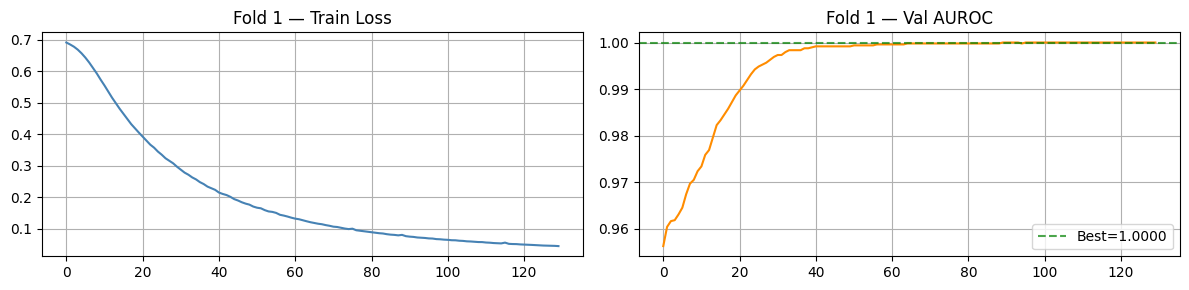



  FOLD 2 / 5


  Train 595 | Val 149 | pos train=67.7% val=67.8%
  class_weight: neg=1.549, pos=0.738
  Early stop @ epoch 66  best AUROC=0.9957
  Threshold(MCC)=0.4
  AUROC=0.9957  Acc=0.9866  Sens=0.9901  Spec=0.9792
  PPV=0.9901  NPV=0.9792  Kappa=0.9693  MCC=0.9693


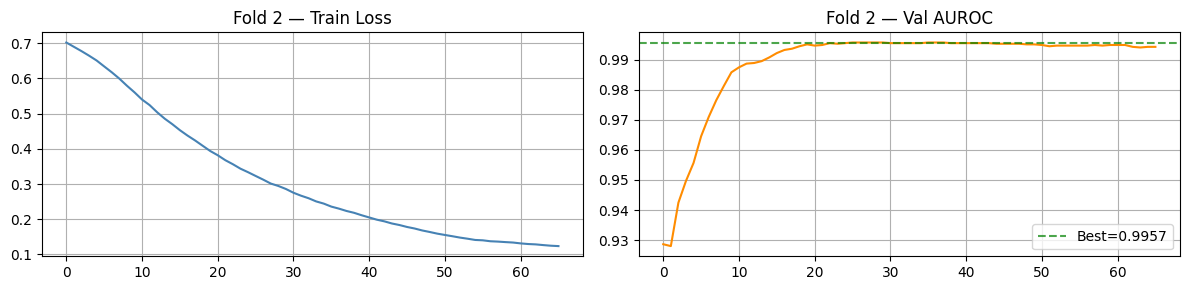



  FOLD 3 / 5


  Train 595 | Val 149 | pos train=67.7% val=67.8%
  class_weight: neg=1.549, pos=0.738
  Early stop @ epoch 76  best AUROC=1.0000
  Threshold(MCC)=0.42
  AUROC=1.0  Acc=1.0  Sens=1.0  Spec=1.0
  PPV=1.0  NPV=1.0  Kappa=1.0  MCC=1.0


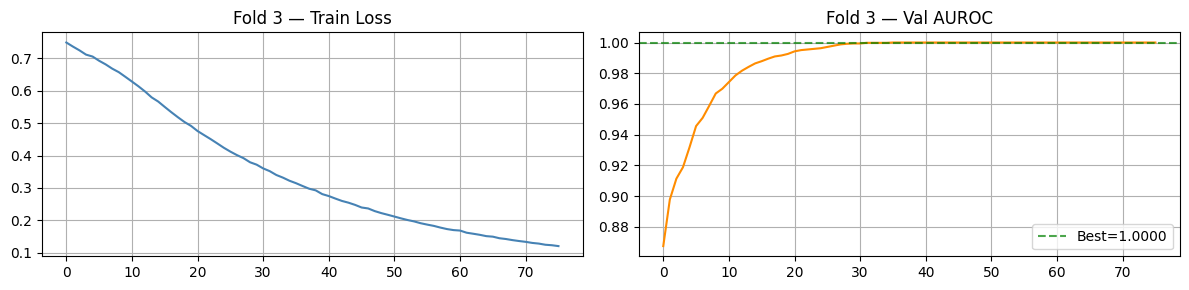



  FOLD 4 / 5


  Train 595 | Val 149 | pos train=67.7% val=67.8%
  class_weight: neg=1.549, pos=0.738
  Early stop @ epoch 73  best AUROC=1.0000
  Threshold(MCC)=0.52
  AUROC=1.0  Acc=0.9933  Sens=0.9901  Spec=1.0
  PPV=1.0  NPV=0.9796  Kappa=0.9847  MCC=0.9848


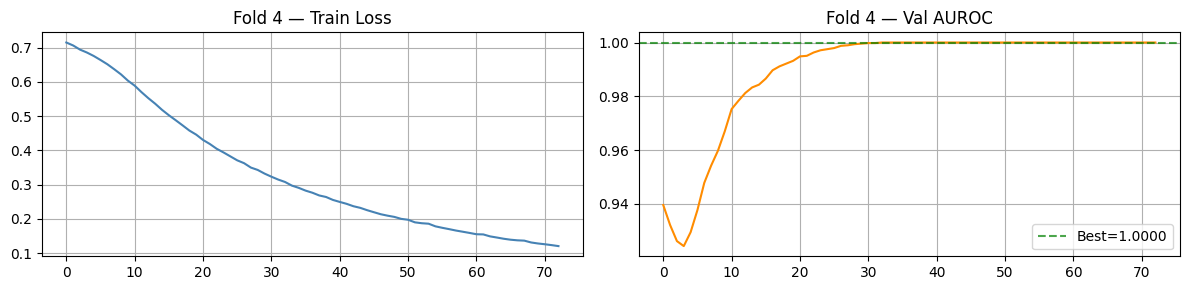



  FOLD 5 / 5


  Train 596 | Val 148 | pos train=67.8% val=67.6%
  class_weight: neg=1.552, pos=0.738
  Early stop @ epoch 80  best AUROC=1.0000
  Threshold(MCC)=0.55
  AUROC=1.0  Acc=1.0  Sens=1.0  Spec=1.0
  PPV=1.0  NPV=1.0  Kappa=1.0  MCC=1.0


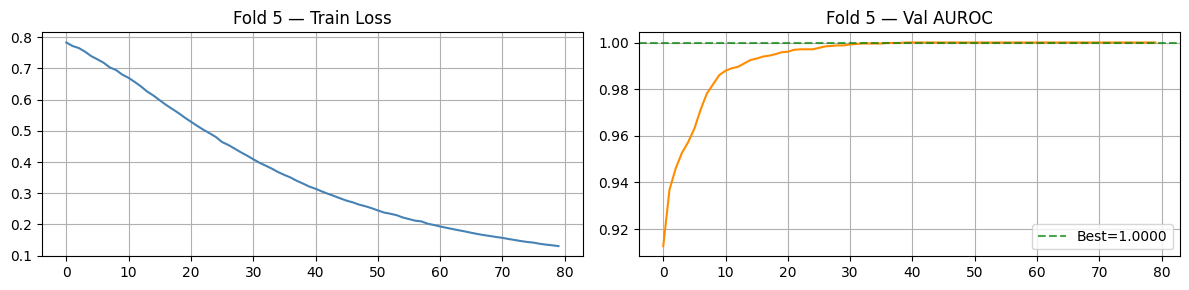

Thresholds các fold : [0.4, 0.4, 0.42, 0.52, 0.55]
Mean threshold      : 0.458


In [11]:
from sklearn.model_selection import StratifiedKFold
from IPython.display import clear_output

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_records    = []   # metrics dict mỗi fold
fold_thresholds = []   # MCC-optimal threshold mỗi fold
fold_states     = []   # best model state_dict mỗi fold
fold_qts        = []   # QuantileTransformer mỗi fold

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_dev, y_dev), start=1):
    print(f'\n')
    print(f'  FOLD {fold} / {N_FOLDS}')
    print(f'\n')

    X_tr,  X_val  = X_dev[tr_idx],  X_dev[val_idx]
    y_tr,  y_val  = y_dev[tr_idx],  y_dev[val_idx]
    print(f'  Train {len(y_tr)} | Val {len(y_val)} | '
          f'pos train={y_tr.mean():.1%} val={y_val.mean():.1%}')

    qt_fold = QuantileTransformer(output_distribution='normal',
                                   random_state=SEED,
                                   n_quantiles=min(len(X_tr), 1000))
    qt_fold.fit(X_tr)
    X_tr_t  = qt_fold.transform(X_tr).astype(np.float32)
    X_val_t = qt_fold.transform(X_val).astype(np.float32)
    fold_qts.append(qt_fold)

    # Class-weighted BCE loss 
    n_neg, n_pos  = (y_tr==0).sum(), (y_tr==1).sum()
    w_neg = len(y_tr) / (2 * n_neg)
    w_pos = len(y_tr) / (2 * n_pos)
    class_w = torch.tensor([w_neg, w_pos], dtype=torch.float32, device=device)
    print(f'  class_weight: neg={w_neg:.3f}, pos={w_pos:.3f}')

    torch.manual_seed(SEED + fold)
    np.random.seed(SEED + fold)
    model_fold = build_model(X_tr_t.shape[1], NUM_TREES, NUM_LAYERS, TREE_DIM, DEPTH)

    with torch.no_grad():
        init_x = torch.as_tensor(X_tr_t[:min(len(X_tr_t), 1000)], device=device)
        _ = model_fold(init_x)  # data-aware init

    opt  = torch.optim.Adam(model_fold.parameters(), lr=LR, weight_decay=1e-5)
    sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(
               opt, patience=15, factor=0.5, min_lr=1e-5)

    best_auroc = 0.0
    best_state = None
    no_improve = 0
    loss_hist, auroc_hist = [], []

    for epoch in range(1, MAX_EPOCHS + 1):
        model_fold.train()
        ep_losses = []
        for xb, yb in iterate_minibatches(X_tr_t, y_tr, batch_size=BATCH_SIZE):
            xb = torch.as_tensor(xb, device=device)
            yb = torch.as_tensor(yb, device=device)
            opt.zero_grad()
            loss = F.cross_entropy(model_fold(xb), yb, weight=class_w)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_fold.parameters(), 1.0)
            opt.step()
            ep_losses.append(loss.item())

        val_probs = predict_proba(model_fold, X_val_t)
        val_auroc = roc_auc_score(y_val, val_probs)
        sch.step(-val_auroc)   # maximize AUROC = minimize -AUROC

        loss_hist.append(np.mean(ep_losses))
        auroc_hist.append(val_auroc)

        if val_auroc > best_auroc:
            best_auroc = val_auroc
            best_state = {k: v.clone() for k, v in model_fold.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= PATIENCE:
            print(f'  Early stop @ epoch {epoch}  best AUROC={best_auroc:.4f}')
            break

    model_fold.load_state_dict(best_state)
    fold_states.append(best_state)

    val_probs_best = predict_proba(model_fold, X_val_t)
    best_thr, best_mcc_val = tune_threshold_mcc(y_val, val_probs_best)
    fold_thresholds.append(best_thr)

    m = compute_metrics(y_val, val_probs_best, best_thr)
    m.update({'Fold': fold, 'Threshold': best_thr,
              'BestEpoch': len(loss_hist) - no_improve})
    fold_records.append(m)

    print(f'  Threshold(MCC)={best_thr}')
    print(f'  AUROC={m["AUROC"]}  Acc={m["Accuracy"]}  '
          f'Sens={m["Sensitivity"]}  Spec={m["Specificity"]}')
    print(f'  PPV={m["PPV"]}  NPV={m["NPV"]}  '
          f'Kappa={m["Kappa"]}  MCC={m["MCC"]}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    axes[0].plot(loss_hist, color='steelblue')
    axes[0].set_title(f'Fold {fold} — Train Loss'); axes[0].grid(True)
    axes[1].plot(auroc_hist, color='darkorange')
    axes[1].axhline(best_auroc, ls='--', color='green', alpha=.7,
                    label=f'Best={best_auroc:.4f}')
    axes[1].set_title(f'Fold {fold} — Val AUROC')
    axes[1].legend(); axes[1].grid(True)
    plt.tight_layout(); plt.show()

print(f'Thresholds các fold : {fold_thresholds}')
print(f'Mean threshold      : {np.mean(fold_thresholds):.3f}')


In [12]:
df_folds = pd.DataFrame(fold_records)
df_folds = df_folds[['Fold'] + METRIC_COLS + ['Threshold','BestEpoch','TP','TN','FP','FN']]

print('Kết quả từng fold:')
print(df_folds[['Fold'] + METRIC_COLS + ['Threshold']].to_string(index=False))


Kết quả từng fold:
 Fold  AUROC  Accuracy  Sensitivity  Specificity    PPV    NPV  Kappa    MCC  Threshold
    1 1.0000    1.0000       1.0000       1.0000 1.0000 1.0000 1.0000 1.0000       0.40
    2 0.9957    0.9866       0.9901       0.9792 0.9901 0.9792 0.9693 0.9693       0.40
    3 1.0000    1.0000       1.0000       1.0000 1.0000 1.0000 1.0000 1.0000       0.42
    4 1.0000    0.9933       0.9901       1.0000 1.0000 0.9796 0.9847 0.9848       0.52
    5 1.0000    1.0000       1.0000       1.0000 1.0000 1.0000 1.0000 1.0000       0.55


In [13]:
summary_rows = []
for col in METRIC_COLS + ['Threshold']:
    v = df_folds[col].values.astype(float)
    summary_rows.append({
        'Metric':   col,
        **{f'Fold_{i+1}': round(v[i], 4) for i in range(N_FOLDS)},
        'Mean':     round(v.mean(), 4),
        'SD':       round(v.std(ddof=1), 4),
        'Mean±SD':  f'{v.mean():.4f} ± {v.std(ddof=1):.4f}',
        'Min':      round(v.min(), 4),
        'Max':      round(v.max(), 4),
    })

df_summary = pd.DataFrame(summary_rows)
print('Tổng hợp 5-Fold CV (Mean ± SD):')
print(df_summary[['Metric','Mean±SD','Min','Max']].to_string(index=False))

Tổng hợp 5-Fold CV (Mean ± SD):
     Metric         Mean±SD    Min  Max
      AUROC 0.9991 ± 0.0019 0.9957 1.00
   Accuracy 0.9960 ± 0.0060 0.9866 1.00
Sensitivity 0.9960 ± 0.0054 0.9901 1.00
Specificity 0.9958 ± 0.0093 0.9792 1.00
        PPV 0.9980 ± 0.0044 0.9901 1.00
        NPV 0.9918 ± 0.0113 0.9792 1.00
      Kappa 0.9908 ± 0.0137 0.9693 1.00
        MCC 0.9908 ± 0.0137 0.9693 1.00
  Threshold 0.4580 ± 0.0716 0.4000 0.55


In [14]:
df_folds.to_csv('fold_metrics.csv',         index=False)
df_summary.to_csv('fold_metrics_summary.csv', index=False)
print('Đã lưu:')
print('   fold_metrics.csv          — chỉ số từng fold')
print('   fold_metrics_summary.csv  — Mean ± SD')

Đã lưu:
   fold_metrics.csv          — chỉ số từng fold
   fold_metrics_summary.csv  — Mean ± SD


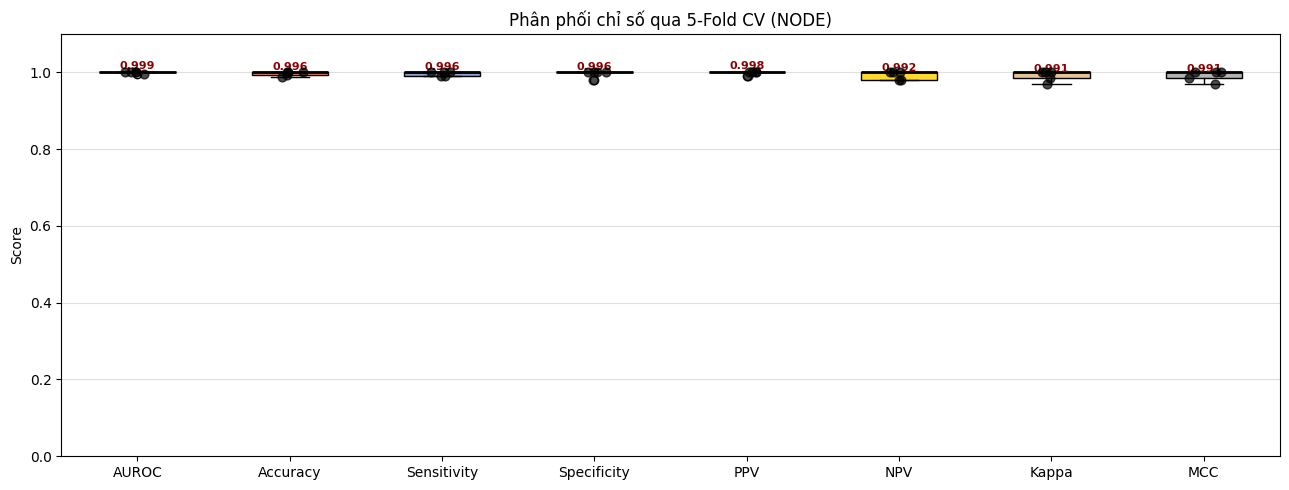

In [15]:
vals = df_folds[METRIC_COLS].values.astype(float)

fig, ax = plt.subplots(figsize=(13, 5))
bp = ax.boxplot(vals, patch_artist=True, labels=METRIC_COLS,
                medianprops=dict(color='black', lw=2))
for patch, color in zip(bp['boxes'], plt.cm.Set2(np.linspace(0,1,len(METRIC_COLS)))):
    patch.set_facecolor(color)

for i, col in enumerate(METRIC_COLS):
    y = df_folds[col].values.astype(float)
    ax.scatter(np.random.normal(i+1, 0.04, len(y)), y,
               s=40, color='black', zorder=5, alpha=0.7)
    ax.text(i+1, y.mean()+0.005, f'{y.mean():.3f}',
            ha='center', va='bottom', fontsize=8, color='darkred', fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Phân phối chỉ số qua 5-Fold CV (NODE)')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()


In [16]:
FINAL_THRESHOLD = round(float(np.mean(fold_thresholds)), 3)
print(f'Threshold các fold : {fold_thresholds}')
print(f'Mean threshold     : {FINAL_THRESHOLD}')

Threshold các fold : [0.4, 0.4, 0.42, 0.52, 0.55]
Mean threshold     : 0.458


In [17]:
ensemble_probs = np.zeros(len(X_test))

for fold_i, (state, qt_i) in enumerate(zip(fold_states, fold_qts), start=1):
    m_i = build_model(X_test.shape[1], NUM_TREES, NUM_LAYERS, TREE_DIM, DEPTH)
    m_i.load_state_dict(state)
    X_test_t = qt_i.transform(X_test).astype(np.float32)
    p_i = predict_proba(m_i, X_test_t)
    ensemble_probs += p_i
    print(f'  Fold {fold_i} AUROC on test: {roc_auc_score(y_test, p_i):.4f}')

ensemble_probs /= N_FOLDS
print(f'\nEnsemble AUROC: {roc_auc_score(y_test, ensemble_probs):.4f}')

  Fold 1 AUROC on test: 1.0000
  Fold 2 AUROC on test: 0.9992
  Fold 3 AUROC on test: 1.0000
  Fold 4 AUROC on test: 1.0000
  Fold 5 AUROC on test: 1.0000

Ensemble AUROC: 1.0000


In [18]:
test_metrics = compute_metrics(y_test, ensemble_probs, FINAL_THRESHOLD)

print('='*60)
print('        KẾT QUẢ TRÊN TẬP TEST ĐỘC LẬP')
print('='*60)
for k, v in test_metrics.items():
    if k not in ('TP','TN','FP','FN'):
        print(f'  {k:<15}: {v}')
print(f'  Threshold      : {FINAL_THRESHOLD}  (mean MCC threshold)')
print(f'  TP={test_metrics["TP"]}  TN={test_metrics["TN"]}  '
      f'FP={test_metrics["FP"]}  FN={test_metrics["FN"]}')

        KẾT QUẢ TRÊN TẬP TEST ĐỘC LẬP
  AUROC          : 1.0
  Accuracy       : 1.0
  Sensitivity    : 1.0
  Specificity    : 1.0
  PPV            : 1.0
  NPV            : 1.0
  Kappa          : 1.0
  MCC            : 1.0
  Threshold      : 0.458  (mean MCC threshold)
  TP=127  TN=60  FP=0  FN=0


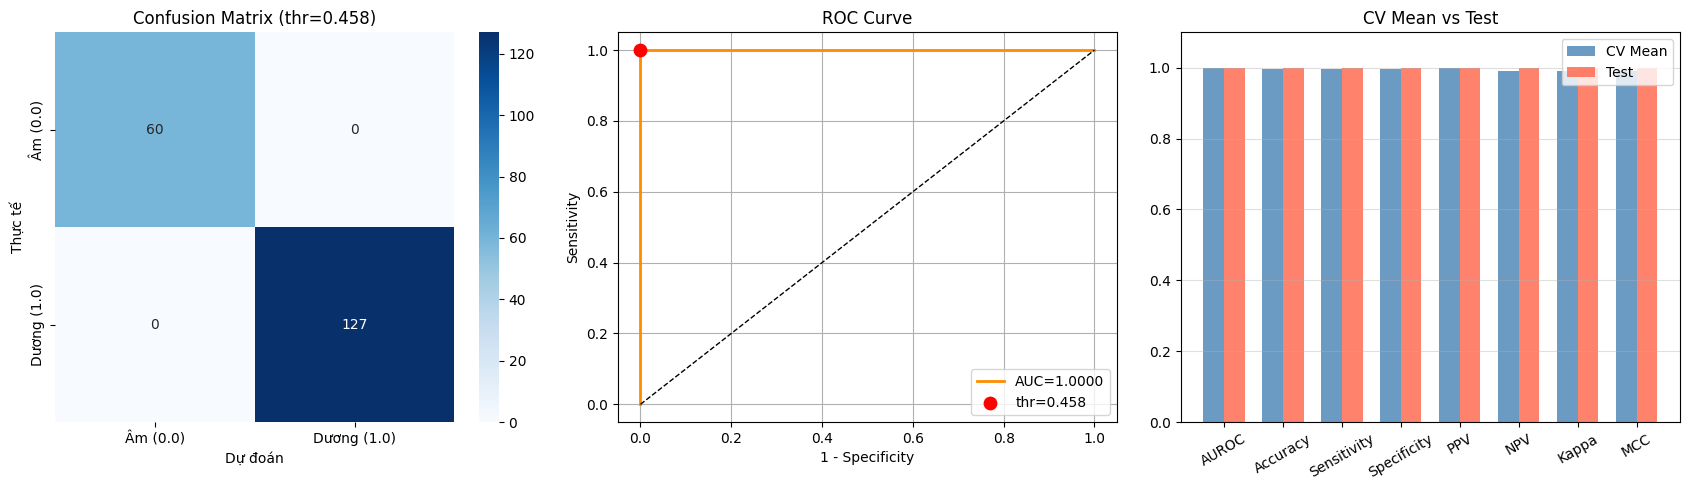

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, (ensemble_probs >= FINAL_THRESHOLD).astype(int))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Âm ({LABEL_NAMES[0]})', f'Dương ({LABEL_NAMES[1]})'],
            yticklabels=[f'Âm ({LABEL_NAMES[0]})', f'Dương ({LABEL_NAMES[1]})'],
            ax=axes[0])
axes[0].set_xlabel('Dự đoán'); axes[0].set_ylabel('Thực tế')
axes[0].set_title(f'Confusion Matrix (thr={FINAL_THRESHOLD})')

fpr, tpr, thrs_roc = roc_curve(y_test, ensemble_probs)
auc_val = roc_auc_score(y_test, ensemble_probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={auc_val:.4f}')
axes[1].plot([0,1],[0,1],'k--',lw=1)
best_idx = np.argmin(abs(thrs_roc - FINAL_THRESHOLD))
axes[1].scatter(fpr[best_idx], tpr[best_idx], s=80, c='red', zorder=5,
                label=f'thr={FINAL_THRESHOLD}')
axes[1].set_xlabel('1 - Specificity'); axes[1].set_ylabel('Sensitivity')
axes[1].set_title('ROC Curve'); axes[1].legend(); axes[1].grid(True)

cv_means  = df_summary.set_index('Metric')['Mean']
test_vals = [test_metrics[m] for m in METRIC_COLS]
cv_vals   = [float(cv_means[m]) for m in METRIC_COLS]
x = np.arange(len(METRIC_COLS)); w = 0.35
axes[2].bar(x-w/2, cv_vals,  w, label='CV Mean', color='steelblue', alpha=0.8)
axes[2].bar(x+w/2, test_vals, w, label='Test',    color='tomato',    alpha=0.8)
axes[2].set_xticks(x); axes[2].set_xticklabels(METRIC_COLS, rotation=30)
axes[2].set_ylim(0, 1.1); axes[2].legend(); axes[2].grid(axis='y', alpha=0.4)
axes[2].set_title('CV Mean vs Test')

plt.tight_layout(); plt.show()

In [20]:
test_row = {'Fold': 'TEST', 'Threshold': FINAL_THRESHOLD, 'BestEpoch': '-',
            'TP': test_metrics['TP'], 'TN': test_metrics['TN'],
            'FP': test_metrics['FP'], 'FN': test_metrics['FN']}
for col in METRIC_COLS:
    test_row[col] = test_metrics[col]

df_folds_final = pd.concat([df_folds, pd.DataFrame([test_row])], ignore_index=True)
df_folds_final.to_csv('fold_metrics.csv', index=False)

test_summary_rows = []
for col in METRIC_COLS + ['Threshold']:
    val = test_metrics.get(col, FINAL_THRESHOLD if col=='Threshold' else '-')
    row = {'Metric': col, 'Mean±SD': f'TEST={val}', 'Min': '-', 'Max': '-'}
    for i in range(N_FOLDS): row[f'Fold_{i+1}'] = '-'
    row['Mean'] = val; row['SD'] = '-'
    test_summary_rows.append(row)

df_summary_final = pd.concat([df_summary, pd.DataFrame(test_summary_rows)], ignore_index=True)
df_summary_final.to_csv('fold_metrics_summary.csv', index=False)

print('   fold_metrics.csv          — 5 fold + dòng TEST')
print('   fold_metrics_summary.csv  — Mean±SD + TEST')
print()
print('Preview fold_metrics.csv:')
df_folds_final[['Fold'] + METRIC_COLS + ['Threshold']]


   fold_metrics.csv          — 5 fold + dòng TEST
   fold_metrics_summary.csv  — Mean±SD + TEST

Preview fold_metrics.csv:


,Fold,AUROC,Accuracy,Sensitivity,Specificity,PPV,NPV,Kappa,MCC,Threshold
0,1,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.400
1,2,0.9957,0.9866,0.9901,0.9792,0.9901,0.9792,0.9693,0.9693,0.400
2,3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.420
3,4,1.0000,0.9933,0.9901,1.0000,1.0000,0.9796,0.9847,0.9848,0.520
4,5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.550
5,TEST,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.458
